In [1]:
from pathlib import Path
import pandas as pd

from fundrating import MVSK, LMoments, TLMoments, TF_RA, TF_RL, MVSKRating

import ffn
import bt

In [8]:
prices = pd.read_parquet('./prices.parquet')
prices

,1,2,4,20,39,41,43,44,45,46,...,2534,2535,2536,2537,2538,2550,2554,2555,2556,2557
2010-05-14,5.476645,1.227498,1.101210,6.391235,3.493413,4.921471,2.108700,0.383549,0.880265,1.298022,...,NaN,2.604245,2.007951,3.074016,NaN,10.661900,NaN,125.211225,158.739448,559.565586
2010-05-17,5.414412,1.211132,1.092616,6.330716,3.437313,4.882201,2.082511,0.383744,0.847512,1.288115,...,NaN,2.557511,1.999445,3.032510,NaN,10.604300,NaN,125.355953,158.922930,560.212370
2010-05-18,5.408000,1.218541,1.088438,6.349064,3.435206,4.862264,2.094496,0.377476,0.842932,1.283535,...,NaN,2.544900,1.995313,3.048979,NaN,10.454800,NaN,124.660637,159.262748,554.825716
2010-05-19,5.338992,1.184981,1.061882,6.172031,3.358706,4.758556,2.035721,0.384784,0.832573,1.251945,...,NaN,2.491079,1.968174,2.954590,NaN,10.326899,NaN,116.870557,149.672211,531.458445
2010-05-20,5.223289,1.176284,1.048949,6.159863,3.279632,4.708382,2.025996,0.375743,0.802628,1.247837,...,NaN,2.416815,1.877554,2.915486,NaN,10.176400,NaN,111.514749,143.072262,512.346458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-06,8.760877,3.203071,2.746837,21.216310,6.051694,7.365633,4.709706,0.774419,1.496024,2.171534,...,5.902752,NaN,9.039805,8.068392,2.771594,23.940500,297.042059,333.913793,426.545384,2005.883078
2025-05-07,8.761494,3.219830,2.733851,21.302874,6.047891,7.328335,4.712807,0.773827,1.501560,2.162388,...,5.895712,NaN,9.035231,8.095727,2.772654,24.033600,296.124801,332.871615,427.290908,1991.944158
2025-05-08,8.812671,3.265731,2.760488,21.704704,6.076290,7.412026,4.762107,0.773975,1.508296,2.183370,...,5.970632,NaN,9.289354,8.263760,2.838381,24.033600,296.310164,332.881041,425.298320,1989.754559
2025-05-09,8.868259,3.252612,2.751148,21.594619,6.114727,7.396818,4.754880,0.780830,1.519625,2.176122,...,5.956884,NaN,9.311395,8.262889,2.839704,24.359800,300.464416,337.563758,428.647041,2027.421345


In [10]:
index_startdate = prices.index[1] + pd.DateOffset(years=5) - pd.DateOffset(months=1)
index_rebdate = index_startdate + pd.DateOffset(months=1)
s = bt.Strategy(name='MVSKRating', algos=[
        bt.algos.RunAfterDate(date=index_rebdate - pd.DateOffset(months=1)),
        bt.algos.RunOnce(),
        bt.algos.SelectAll(),
        MVSKRating(moment_generating_func=MVSK, getXYgXgY=TF_RA, nselectassets=30, useConvex=False, max_window_years=5, nr_moments=4),
        bt.algos.Rebalance(),
    ])
backtest = bt.Backtest(s, prices.fillna(0.0))

In [11]:
res = bt.run(backtest)

  0%|          | 0/1 [00:00<?, ?it/s]/home/kepiej/Documents/Code/fundrating/.venv/lib/python3.12/site-packages/scipy/stats/_stats_py.py:1127: RuntimeWarning: invalid value encountered in subtract
  a_zero_mean = a - mean
100%|██████████| 1/1 [00:09<00:00,  9.13s/it]


In [12]:
res.display()

Stat                 MVSKRating
-------------------  ------------
Start                2010-05-13
End                  2025-05-12
Risk-free rate       0.00%

Total Return         48.21%
Daily Sharpe         0.29
Daily Sortino        0.41
CAGR                 2.66%
Max Drawdown         -35.04%
Calmar Ratio         0.08

MTD                  5.71%
3m                   -4.63%
6m                   -1.30%
YTD                  -1.73%
1Y                   3.20%
3Y (ann.)            6.31%
5Y (ann.)            8.35%
10Y (ann.)           4.22%
Since Incep. (ann.)  2.66%

Daily Sharpe         0.29
Daily Sortino        0.41
Daily Mean (ann.)    3.09%
Daily Vol (ann.)     10.54%
Daily Skew           -1.70
Daily Kurt           23.83
Best Day             6.13%
Worst Day            -9.14%

Monthly Sharpe       0.29
Monthly Sortino      0.45
Monthly Mean (ann.)  3.25%
Monthly Vol (ann.)   11.15%
Monthly Skew         -0.49
Monthly Kurt         3.69
Best Month           11.08%
Worst Month          -14.52

<Axes: title={'center': 'Equity Progression'}>

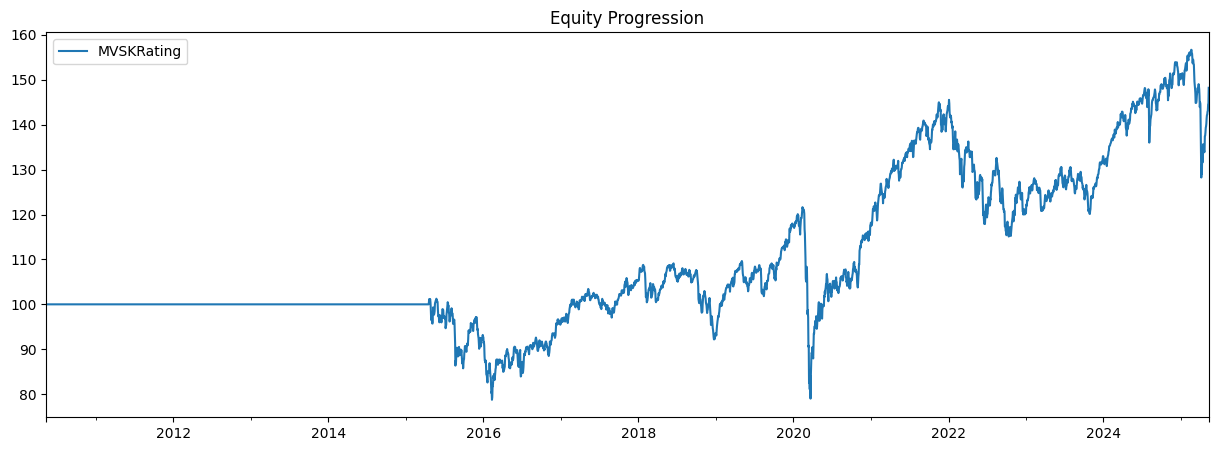

In [13]:
res.plot()